In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
# Sigmoid activation function where sum of w's and b's is fed
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [4]:
# Generate dataset of values b/w -10 and 10 with interval of .5
X = np.arange(-10, 11, 0.5)
# The actual parameters of w and b
# w = 2
# b = -3
y = (sigmoid(2 * X - 3) >= 0.5).astype(int)
X, y

(array([-10. ,  -9.5,  -9. ,  -8.5,  -8. ,  -7.5,  -7. ,  -6.5,  -6. ,
         -5.5,  -5. ,  -4.5,  -4. ,  -3.5,  -3. ,  -2.5,  -2. ,  -1.5,
         -1. ,  -0.5,   0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,
          3.5,   4. ,   4.5,   5. ,   5.5,   6. ,   6.5,   7. ,   7.5,
          8. ,   8.5,   9. ,   9.5,  10. ,  10.5]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [5]:
X[23],y[23] # Decision boundary     

(np.float64(1.5), np.int64(1))

In [6]:
len(X), len(y)

(42, 42)

In [7]:
# shuffling data so that training / testing has both +ive and -ive items
np.random.seed(42)
perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]
X, y

(array([  2.5,  -3.5,  -6. ,   3. ,  -8. ,   9.5,  -0.5,   4.5,   5. ,
         -7. ,   3.5,  -4. ,  -1.5,  -5.5,  -2.5,   6.5,  -2. ,   8. ,
          7.5, -10. ,   2. ,  -7.5,  -4.5,  10. ,  -9.5,   5.5,   0.5,
         -9. ,   6. ,  10.5,  -8.5,   8.5,   1.5,   7. ,  -5. ,   1. ,
         -1. ,   0. ,  -6.5,  -3. ,   4. ,   9. ]),
 array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1]))

In [8]:
X_train, X_test, y_train, y_test = X[:30], X[30:], y[:30], y[30:]
X_train, X_test, y_train, y_test

(array([  2.5,  -3.5,  -6. ,   3. ,  -8. ,   9.5,  -0.5,   4.5,   5. ,
         -7. ,   3.5,  -4. ,  -1.5,  -5.5,  -2.5,   6.5,  -2. ,   8. ,
          7.5, -10. ,   2. ,  -7.5,  -4.5,  10. ,  -9.5,   5.5,   0.5,
         -9. ,   6. ,  10.5]),
 array([-8.5,  8.5,  1.5,  7. , -5. ,  1. , -1. ,  0. , -6.5, -3. ,  4. ,
         9. ]),
 array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 1, 1]),
 array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1]))

In [9]:
# Start model with random values of w and b
w = np.random.rand()
b = np.random.rand()
w,b

(0.450499251969543, 0.013264961159866528)

In [10]:
# Predict the values of training data based on random weights
Z = w * X_train + b
# Probabilities
y_prob = sigmoid(Z)

# Convert to labels only for accuracy
y_train_pred = (sigmoid(Z) >= 0.5).astype(int)
evl = np.array(y_train_pred == y_train)
evl

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True])

In [11]:
right = np.sum(evl == True)
wrong = np.sum(evl == False)
right, wrong

(np.int64(29), np.int64(1))

In [12]:
accuracy = np.mean(y_train_pred == y_train)
accuracy

np.float64(0.9666666666666667)

In [13]:
tp = np.sum((y_train_pred == 1) & (y_train == 1))

In [14]:
recall = tp / np.sum(y_train == 1)
recall

np.float64(1.0)

In [15]:
precision = tp / max(np.sum(y_train_pred == 1), 1)
precision

np.float64(0.9333333333333333)

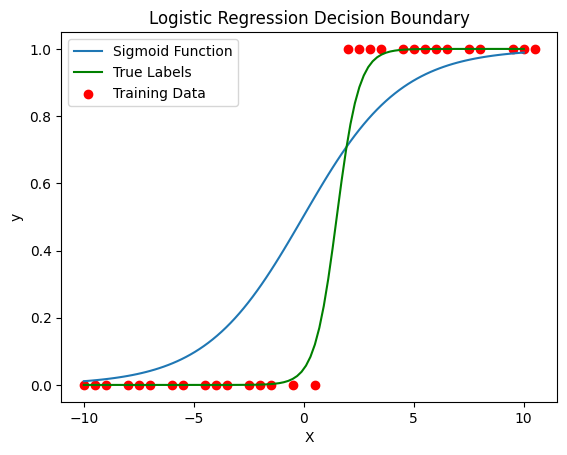

In [16]:
# plotting the decision boundary
x_values = np.linspace(-10, 10, 100)
z_values = w * x_values + b
y_values = sigmoid(z_values)
plt.plot(x_values, y_values, label='Sigmoid Function')
plt.plot(x_values, sigmoid(2 * x_values - 3), c="g", label="True Labels")
plt.scatter(X_train, y_train, color='red', label='Training Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

Text(0.5, 0, 'Recall')

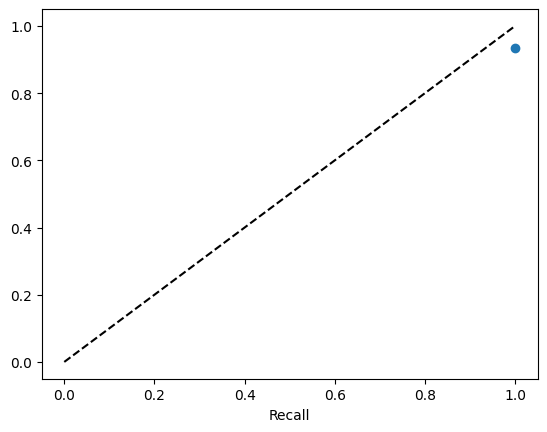

In [17]:
# plotting roc curve
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.plot(recall, precision, marker='o', label='ROC Curve')
plt.xlabel('Recall')

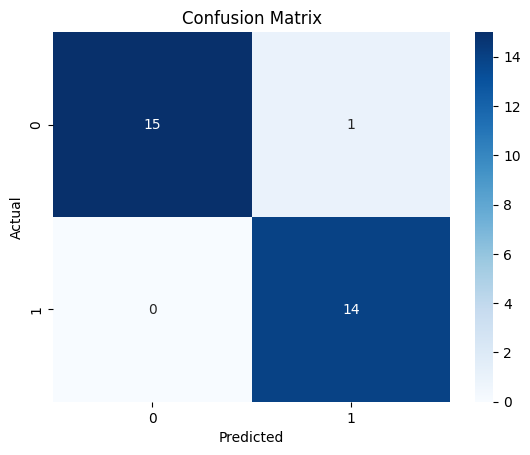

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [19]:
# Loss function
def binary_cross_entropy(y_true, y_prob):
    epsilon = 1e-15

    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_prob) +
        (1 - y_true) * np.log(1 - y_prob)
    )

    return loss

In [20]:
binary_cross_entropy(y_train, y_prob)

np.float64(0.1585521489165684)

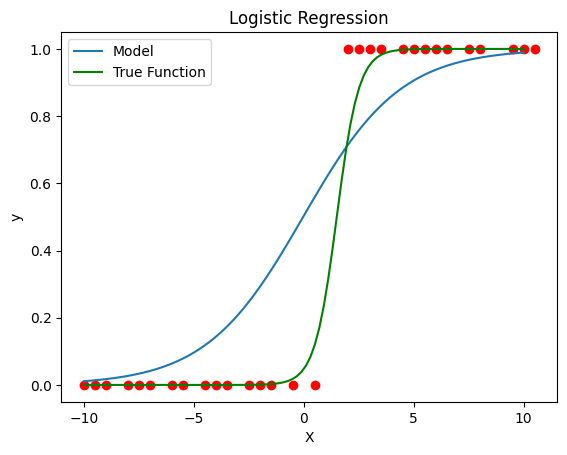

In [21]:
# -----------------------------
# PLOT SIGMOID
# -----------------------------

x_values = np.linspace(-10, 10, 100)

y_values = sigmoid(w * x_values + b)

plt.plot(x_values, y_values, label='Model')

plt.plot(
    x_values,
    sigmoid(2 * x_values - 3),
    c='green',
    label='True Function'
)

plt.scatter(X_train, y_train, color='red')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Logistic Regression')
plt.legend()
plt.show()

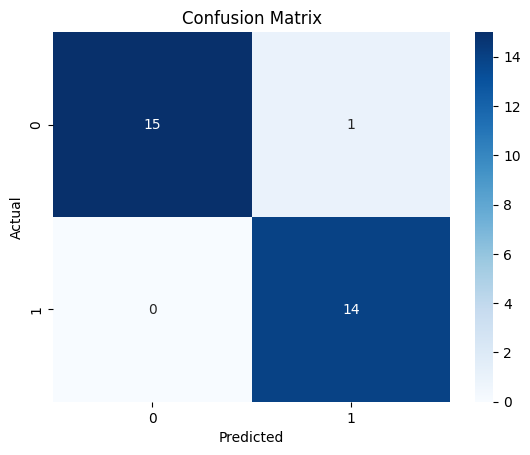

In [23]:
# -----------------------------
# CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(y_train, y_train_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()